In [11]:
# Step 2: Collect and Understand Dataset

import pandas as pd

# Load Dataset
df = pd.read_csv("E:\Artificial Intelligence\spam.csv", encoding='latin-1')

# Keep only useful columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'text']

# Show first 5 rows
print(df.head())

# Check dataset info
print(df.info())

# Check missing values
print(df.isnull().sum())

# Check class distribution
print(df['label'].value_counts())

  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
label    0
text     0
dtype: int64
label
ham     4825
spam     747
Name: count, dtype: int64


In [12]:
#Step 3: Split the Data

from sklearn.model_selection import train_test_split

# Features and Labels
X = df['text']
y = df['label']

# Convert labels into numbers
# spam = 1, ham = 0
y = y.map({'ham':0, 'spam':1})

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 4457
Testing Samples: 1115


In [17]:
#Step 4: Text Tokenization

from transformers import DistilBertTokenizer

# Load Tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Example Tokenization
sample_text = X_train.iloc[0]

encoding = tokenizer(
    sample_text,
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors='pt'
)

print(encoding)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\itsay\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\itsay\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

{'input_ids': tensor([[ 101, 2183, 2006, 2498, 2307, 1012, 9061,  102,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0,

In [19]:
#Step 5: Create Dataset Structure

import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_len):

        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):

        text = self.texts[index]
        label = self.labels[index]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [20]:
#Step 6: Load Pre-trained DistilBERT Model

from transformers import DistilBertForSequenceClassification

# Load Model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

print(model)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [21]:
#Step 7: Define Training Strategy

from torch.utils.data import DataLoader

MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5

# Create Dataset Objects
train_dataset = SpamDataset(
    X_train,
    y_train,
    tokenizer,
    MAX_LEN
)

test_dataset = SpamDataset(
    X_test,
    y_test,
    tokenizer,
    MAX_LEN
)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)

print("Training Strategy Ready")

Training Strategy Ready


In [23]:
# Step 8: Train the Model

import torch
from torch.optim import AdamW
from tqdm import tqdm

# Device Selection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
model.to(device)

# Optimizer
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

# Training Loop
train_losses = []

model.train()

for epoch in range(EPOCHS):

    total_loss = 0

    loop = tqdm(train_loader, leave=True)

    for batch in loop:

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        loop.set_description(f"Epoch {epoch+1}")
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1} Loss: {avg_loss}")

Epoch 1: 100%|██████████| 279/279 [12:35<00:00,  2.71s/it, loss=0.0356] 


Epoch 1 Loss: 0.08909649249853893


Epoch 2: 100%|██████████| 279/279 [12:21<00:00,  2.66s/it, loss=0.00123] 


Epoch 2 Loss: 0.01829620043114562


Epoch 3: 100%|██████████| 279/279 [14:40<00:00,  3.16s/it, loss=0.000736]

Epoch 3 Loss: 0.006626070888798958


In [24]:
#Step 9: Evaluate the Model

from sklearn.metrics import accuracy_score

model.eval()

predictions = []
actual_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        actual_labels.extend(labels.cpu().numpy())

# Accuracy
accuracy = accuracy_score(actual_labels, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9919282511210762


In [25]:
#Step 10: Calculate Performance Metrics

from sklearn.metrics import classification_report

# Classification Metrics
report = classification_report(
    actual_labels,
    predictions
)

print(report)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       966
           1       0.97      0.97      0.97       149

    accuracy                           0.99      1115
   macro avg       0.98      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



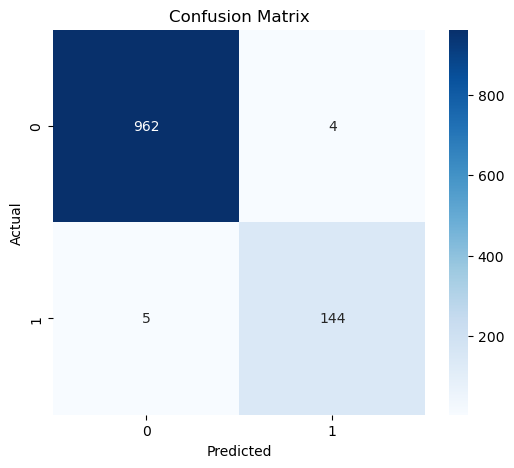

In [26]:
#Step 11: Generate Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(actual_labels, predictions)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

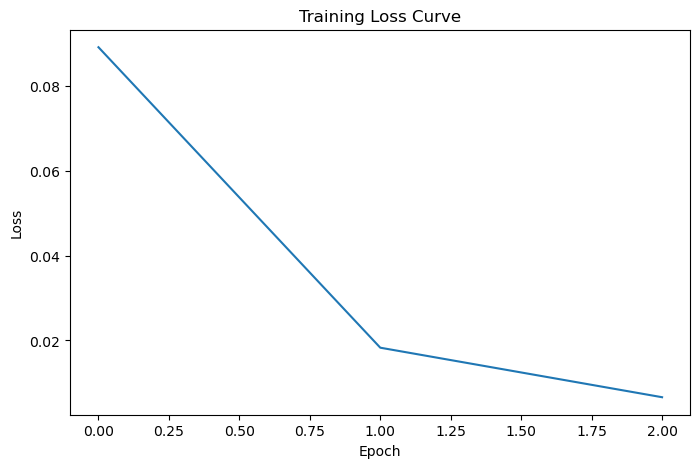

In [27]:
#Step 12: Analyze Training Behavior

# Plot Training Loss

plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.show()

In [28]:
#Step 13: Compare with Traditional Models

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# TF-IDF Feature Extraction
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression
lr_model = LogisticRegression()

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

# Naive Bayes
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

# DistilBERT Accuracy
print("DistilBERT Accuracy:", accuracy)

Logistic Regression Accuracy: 0.9748878923766816
Naive Bayes Accuracy: 0.9641255605381166
DistilBERT Accuracy: 0.9919282511210762


In [29]:
#Step 14: Analyze Computational Cost

import time

# Training Time Example

start = time.time()

# Example dummy loop
for i in range(1000000):
    pass

end = time.time()

print("Execution Time:", end - start)

Execution Time: 0.027380943298339844


In [30]:
#Step 15: Discuss Limitations

limitations = [

    "DistilBERT requires high computational power",
    "Training time is higher than traditional ML models",
    "Needs GPU for faster execution",
    "Large memory consumption",
    "Transformer models are complex to fine-tune"
]

for item in limitations:
    print("-", item)

- DistilBERT requires high computational power
- Training time is higher than traditional ML models
- Needs GPU for faster execution
- Large memory consumption
- Transformer models are complex to fine-tune
